In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
import scipy as sp
import seaborn as sns

In [2]:
in_dir = '../../results/04_single_cell_access_atac/32_plot_footprint'
out_dir = '../../results/04_single_cell_access_atac/34_compare_footprint'
os.makedirs(out_dir, exist_ok=True)

In [3]:
# get motif width from PWM
df = pd.read_csv('~/rgtdata/motifs/jaspar_vertebrates.mtf', sep='\t', header=None, index_col=0)

motif_names, motif_width = [], []

for motif_name in df[1].tolist():
    pwm_filename = f'~/rgtdata/motifs/jaspar_vertebrates/{motif_name}.pwm'
    pwm = pd.read_csv(pwm_filename, sep=" ", header=None)
    
    assert pwm.shape[0] == 4, f"Expected 4 rows in PWM for {motif_name}, got {pwm.shape[0]}"
    
    motif_names.append(motif_name)
    motif_width.append(pwm.shape[1])
    
df_motif = pd.DataFrame({'motif_name': motif_names, 'motif_width': motif_width})

In [4]:
def get_fp_score(signal: np.array, motif_width: int = 10) -> float:
    half_fp_width = motif_width // 2
    signal_length = len(signal)

    assert signal_length >= 2 * half_fp_width + motif_width, f"Signal length {signal_length} is too short for motif width {motif_width}"

    fp_signal = signal[signal_length//2-half_fp_width:signal_length//2+half_fp_width].mean()
    left_signal = signal[signal_length//2-half_fp_width - motif_width:signal_length//2-half_fp_width].mean()
    right_signal = signal[signal_length//2+half_fp_width:signal_length//2+half_fp_width + motif_width].mean()
    fp_height = (left_signal + right_signal) / 2 - fp_signal

    return fp_height

def compute_norm_factors(signals: np.ndarray) -> np.ndarray:
    """Compute normalization factors using the median ratio method."""
    signals = np.sum(signals, axis=2)
    signals_log = np.log(signals + 0.01)
    signals_log = signals_log[:, ~np.isnan(signals_log).any(axis=0)]
    signals_log = signals_log - np.mean(signals_log, axis=0, keepdims=True)
    factors = np.exp(np.median(signals_log, axis=1))

    return factors

In [5]:
cell_types = ['Basal', 'Ciliated', 'Club', 'Tuft', 'Hillock']

# for testing
# df_motif = df_motif.head(100)

In [6]:
for assay in ['ACCESS', 'ATAC']:
    os.makedirs(f'{out_dir}/{assay}', exist_ok=True)

    signals = np.zeros((len(cell_types), len(df_motif), 500))  # cell_type x assay x position
    for i, cell_type in enumerate(cell_types):
        for j, motif_name in enumerate(df_motif['motif_name'].tolist()):
            motif_name_clean = motif_name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")
            df = pd.read_csv(f'{in_dir}/{cell_type}/{assay}/{motif_name_clean}.csv')
            signals[i, j, :] = df['signal'].values

    # norm_factors = compute_norm_factors(signals)
    # dont use compute_norm_factors for footprint normalization
    norm_factors = [1, 1, 1, 1, 1]  # no normalization

    print("Normalization factors:", norm_factors)

    # normalize signals by factor and number of motifs
    df_list = []
    for i, cell_type in enumerate(cell_types):
            for j, motif_name in enumerate(df_motif['motif_name'].tolist()):
                motif_name_clean = motif_name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")

                signals[i, j, :] = signals[i, j, :] / (norm_factors[i])

                df = pd.DataFrame({
                    'position': np.arange(-250, 250),
                    'signal': signals[i, j, :],
                    'data': cell_type,
                    'motif_name': motif_name
                })

                df_list.append(df)

    df = pd.concat(df_list, axis=0, ignore_index=True)
    df.to_csv(f'{out_dir}/{assay}/combined_normalized_signals.csv', index=False)

    for motif_name in df_motif['motif_name'].tolist():
        motif_name_clean = motif_name.replace(" ", "_").replace("/", "_").replace("(", "").replace(")", "")

        df_motif_plot = df[df['motif_name'] == motif_name]

        fig, ax = plt.subplots(figsize=(6, 4))
        sns.lineplot(data=df_motif_plot, x='position', y='signal', hue='data', ax=ax)
        ax.set_title(motif_name)
        fig.savefig(f'{out_dir}/{assay}/{motif_name_clean}.png', dpi=300)
        plt.close()

Normalization factors: [1, 1, 1, 1, 1]
Normalization factors: [1, 1, 1, 1, 1]


In [7]:
df = pd.read_csv(f'{out_dir}/ACCESS/combined_normalized_signals.csv')

In [8]:
df = df[['signal', 'data', 'motif_name']]

In [9]:
# convert to dataframe
df_activity = df.groupby(['motif_name', 'data'])['signal'].sum().reset_index()

In [10]:
# convert to wide format
df_activity_wide = df_activity.pivot(index='motif_name', columns='data', values='signal')

# # compute variance across cell types
# df_activity_wide['variance'] = df_activity_wide.var(axis=1)
# df_activity_wide= df_activity_wide.sort_values(by='variance', ascending=False)

# df_activity_wide = df_activity_wide.head(300)
# df_activity_wide = df_activity_wide.drop(columns=['variance'])

# normalize each row as z-score for heatmap
df_activity_wide = (df_activity_wide.sub(df_activity_wide.mean(axis=1), axis=0)
                                   .div(df_activity_wide.std(axis=1), axis=0))

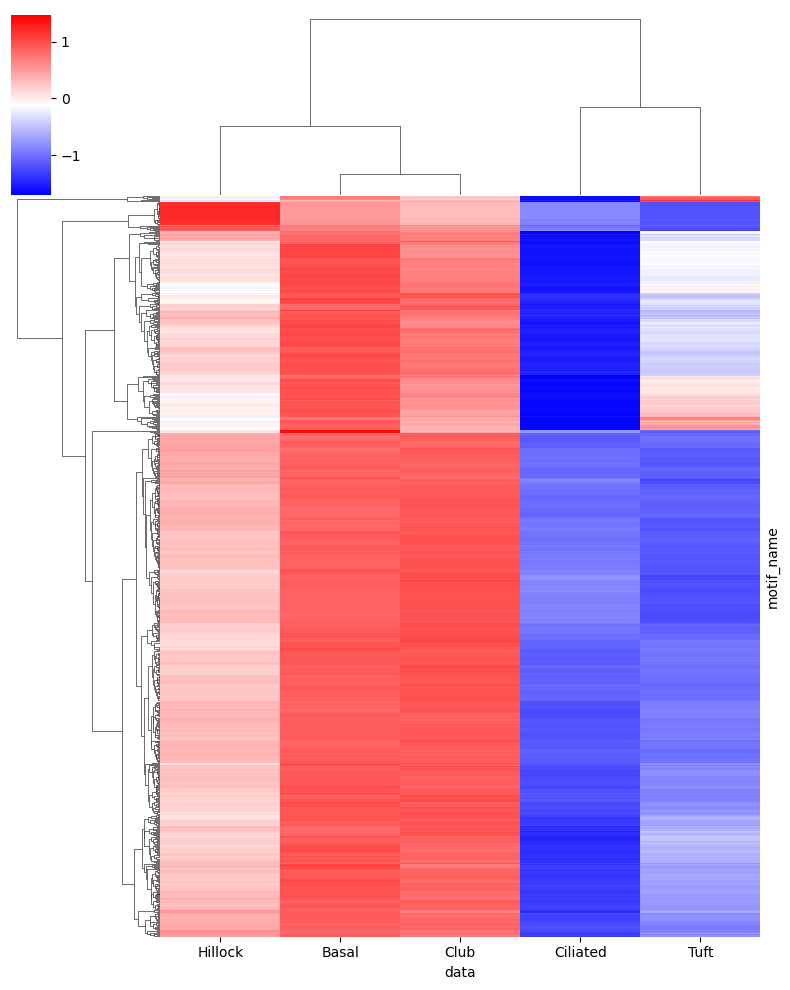

In [11]:
sns.clustermap(df_activity_wide.fillna(0), cmap='bwr', figsize=(8, 10), yticklabels=False)